In [1]:
import gurobipy as gp
from gurobipy import GRB
import itertools
from collections.abc import Mapping, Sequence
import numpy as np

from instance import Instance, Arc, Node

instance = Instance()
world = instance.world
scenarios = instance.scenarios
demands = instance.demands
capacities = instance.capacities
paths_per_od = instance.paths_per_od
active_arcs = instance.active_arcs
arc_to_idx = instance.arc_to_idx
tau = instance.tau
phi = instance.phi

model = gp.Model("asymmetric")
model.setParam("OutputFlag", 0)

V = world.ordered_nodes
A = world.ordered_arcs
I = world.I
N = world.individuals

n = world.total_population
t = world.network.travel_time
c = world.network.capacity
alpha = world.network.bpr_alpha
beta = world.network.bpr_beta

Set parameter Username
Set parameter LicenseID to value 2844113
Academic license - for non-commercial use only - expires 2027-07-13


In [2]:
# TODO: use .fromiter maybe? would need to reshape but should be O(1)

num_arcs = len(active_arcs)
arc_indices = np.arange(num_arcs)

T = {od: i for i, od in enumerate(demands.keys())}
od_list = list(demands.keys())

profiles_per_od = {
    od: list(itertools.combinations_with_replacement(paths_per_od[od], n_k))
    for od, n_k in demands.items()
}

joint_action_profiles = list(itertools.product(*profiles_per_od.values()))
num_joint = len(joint_action_profiles)

path_arc_indices = {
    (od, i): [arc_to_idx[a] for a in path]
    for od, paths in paths_per_od.items()
    for i, path in enumerate(paths)
}


# m := len(profiles_per_od[?])
# m = (n + k - 1) choose (k - 1)
od_path_flows: Mapping[Node, np.ndarray] = {} # (m x num_arcs), possible path flows induced by od
od_arc_flows: Mapping[Node, np.ndarray] = {} # (m x num_arcs), possible arc flows induced by od
for od, paths in paths_per_od.items():
    # (m x k)
    counts = od_path_flows[od] = np.array([
        [profile.count(p) for p in paths]
        for profile in profiles_per_od[od]
    ])

    # map paths to their arcs
    path_to_arcs = np.zeros((len(paths), num_arcs))
    for i, path in enumerate(paths):
        path_to_arcs[i, path_arc_indices[od, i]] = 1

    # (m x num_arcs)
    od_arc_flows[od] = counts @ path_to_arcs


# TODO: optimize combining od flows
# suppose matrices A, B, C:
# A = [a0
#      a1]
# B = [b0
#      b1]
# C = [c0
#      c1]
# add all combinations of rows:
# X = [c0 + a0 + b0
#      c0 + a0 + b1
#      c0 + a1 + b0
#      c0 + a1 + b1
#      c1 + a0 + b0
#      c1 + a0 + b1
#      c1 + a1 + b0
#      c1 + a1 + b1]
# i.e. repeat the left, tile the right

# combine od flows
# (num_joint x num_arcs)
flow_matrix = np.array([
    sum(combo)
    for combo in itertools.product(
        *(od_arc_flows[od] for od in od_list)
    )
], dtype=int)

# TODO: can be similarly optimized to above
path_flows = {
    (od, i): np.array([
        joint_profile[T[od]].count(path)
        for joint_profile in joint_action_profiles
    ])
    for od, paths in paths_per_od.items()
    for i, path in enumerate(paths)
}

path_as_set = {
    path: set(path)
    for paths in paths_per_od.values()
    for path in paths
}

# partition the arcs in p1 into two groups: (p1 & p0, p1 - p0)
partitioned_paths = {}
for od, paths in paths_per_od.items():
    for p0_idx, p0 in enumerate(paths):
        p0_set = path_as_set[p0]
        for p1_idx, p1 in enumerate(paths):
            if p0_idx != p1_idx:
                shared = [arc_to_idx[a] for a in p1 if a in p0_set]
                dev = [arc_to_idx[a] for a in p1 if a not in p0_set]
                partitioned_paths[od, p0_idx, p1_idx] = (shared, dev)

# NOTE: vvv is underestimate b/c of left-facing edges
print(f"{num_arcs=} ({len(active_arcs) / len(A) * 100:.2f}% of arcs)")
print(f"{num_joint=}")

num_arcs=26 (41.94% of arcs)
num_joint=81796


In [3]:
# decision: sigma[omega, a] := \prob[a \mid \theta]
sigma = {}
for scenario_name in scenarios:
    for action_profile_idx in range(len(joint_action_profiles)):
        sigma[scenario_name, action_profile_idx] = model.addVar(
            vtype=GRB.CONTINUOUS, lb=0, ub=1,
            name=f"sigma_{scenario_name}_{action_profile_idx}"
        )

# constraint: \sum_{rho \in \mathcal{A}} sigma[\omega, rho] = 1
for scenario_name in scenarios:
    model.addConstr(
        gp.quicksum(
            sigma[scenario_name, action_profile_idx]
            for action_profile_idx in range(len(joint_action_profiles))
        ) == 1,
        name=f"sigma_{scenario_name}"
    )

In [4]:
def debug_model():
    model.optimize()
    assert model.Status == GRB.OPTIMAL, f"Optimization failed: {model.Status}"

    out = []
    out.append(f"{model.ObjVal=:.2f}")
    out.append(f"{model.Runtime=:.3f}s")

    for scenario_name in scenarios:
        out.append(f"\nState: {scenario_name}")

        for action_profile_idx, joint_profile in enumerate(joint_action_profiles):
            prob = sigma[scenario_name, action_profile_idx].X
            if prob > 1e-3:
                out.append(f"\tJoint Profile {action_profile_idx}: ({prob=:.3f})")
                for od, od_profile in zip(profiles_per_od.keys(), joint_profile):
                    path_flows = tuple(od_profile.count(path) for path in paths_per_od[od])
                    out.append(f"\t\t{od}: {path_flows}")

    return out, model.ObjVal

In [5]:
pot_coeffs = []
cost_coeffs = []
all_sigma_vars = []

for scenario_name, mu in scenarios.items():
    sigma_vars = [sigma[scenario_name, action_profile_idx] for action_profile_idx in range(num_joint)]
    all_sigma_vars.extend(sigma_vars)

    tai_matrix = tau[scenario_name]
    phi_matrix = phi[scenario_name]

    # per joint profile
    potentials = phi_matrix[arc_indices, flow_matrix].sum(axis=1)
    costs = (flow_matrix * tai_matrix[arc_indices, flow_matrix]).sum(axis=1)

    pot_coeffs.extend((mu * potentials).tolist())
    cost_coeffs.extend((mu * costs).tolist())

expected_potential = gp.LinExpr(pot_coeffs, all_sigma_vars) # objective: expected potential
expected_social_cost = gp.LinExpr(cost_coeffs, all_sigma_vars) # objective: expected social cost

In [6]:
model.setObjective(expected_potential, GRB.MINIMIZE)
selfish_out, _ = debug_model()
selfish_cost = expected_social_cost.getValue()

In [7]:
model.setObjective(expected_social_cost, GRB.MINIMIZE)
dictator_out, dictator_cost = debug_model()

In [8]:
# constraint: obedience (IC?)
for od, paths in paths_per_od.items():
    od_idx = T[od]
    expected_deviate_benefit = {
        (p0_idx, p1_idx): ([], [])
        for p0_idx in range(len(paths))
        for p1_idx in range(len(paths))
        if p0_idx != p1_idx
    }

    for scenario_name, mu in scenarios.items():
        sigma_vars = [sigma[scenario_name, action_profile_idx] for action_profile_idx in range(num_joint)]
        tau_matrix = tau[scenario_name]

        # (num_joint x num_arcs)
        # arc_cost = np.column_stack([tau_matrix[i, flow_matrix[:, i]] for i in range(num_arcs)])
        # arc_cost_dev = np.column_stack([tau_matrix[i, flow_matrix[:, i] + 1] for i in range(num_arcs)])
        arc_cost = tau_matrix[arc_indices, flow_matrix]
        arc_cost_dev = tau_matrix[arc_indices, flow_matrix + 1]

        for p0_idx in range(len(paths)):
            # (num_joint,)
            counts = path_flows[od, p0_idx]

            # (num_joint,)
            cost_follow = arc_cost[:, path_arc_indices[od, p0_idx]].sum(axis=1)

            for p1_idx in range(len(paths)):
                if p0_idx == p1_idx:
                    continue

                shared_arcs, dev_arcs = partitioned_paths[od, p0_idx, p1_idx]
                cost_deviate = arc_cost[:, shared_arcs].sum(axis=1)
                cost_deviate += arc_cost_dev[:, dev_arcs].sum(axis=1)

                _coeffs = (mu * counts * (cost_follow - cost_deviate))

                coeffs, vars = expected_deviate_benefit[p0_idx, p1_idx]
                coeffs.extend(_coeffs.ravel())
                vars.extend(sigma_vars)

    for (p0_idx, p1_idx), (coeffs, vars) in expected_deviate_benefit.items():
        model.addConstr(
            gp.LinExpr(coeffs, vars) <= 0,
            name=f"obed_{od}_{p0_idx}_to_{p1_idx}"
        )

In [9]:
shaki_out, shaki_cost = debug_model()

In [10]:
print("Expected Social Costs:")
print(f"\tDICTATOR:\t{dictator_cost:.2f}")
print(f"\tSELFISH:\t{selfish_cost:.2f} ({selfish_cost / dictator_cost:.4f})")
print(f"\tSHAKI:\t\t{shaki_cost:.2f} ({shaki_cost / dictator_cost:.4f})")

Expected Social Costs:
	DICTATOR:	174.04
	SELFISH:	194.71 (1.1188)
	SHAKI:		176.59 (1.0146)


In [11]:
for od, paths in paths_per_od.items():
    print(od)
    for i, path in enumerate(paths):
        print("\t", f"{i}:", path)
    print("\n")

print("="*25)
print("DICTATOR:\n\n")
print("\n".join(dictator_out))
print("\n\n" + "="*25)
print("SELFISH:\n\n")
print("\n".join(selfish_out))
print("\n\n" + "="*25)
print("SHAKI:\n\n")
print("\n".join(shaki_out))

((1, 0), (1, 3))
	 0: (((1, 0), (2, 0)), ((2, 0), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (1, 3)))
	 1: (((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (1, 3)))
	 2: (((1, 0), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (1, 3)))
	 3: (((1, 0), (0, 0)), ((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3)), ((0, 3), (1, 3)))


((3, 0), (3, 3))
	 0: (((3, 0), (2, 0)), ((2, 0), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (3, 3)))
	 1: (((3, 0), (3, 1)), ((3, 1), (3, 2)), ((3, 2), (3, 3)))
	 2: (((3, 0), (3, 1)), ((3, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (3, 2)), ((3, 2), (3, 3)))
	 3: (((3, 0), (4, 0)), ((4, 0), (4, 1)), ((4, 1), (4, 2)), ((4, 2), (4, 3)), ((4, 3), (3, 3)))


DICTATOR:


model.ObjVal=174.04
model.Runtime=0.012s

State: nominal
	Joint Profile 20939: (prob=1.000)
		((1, 0), (1, 3)): (4, 1, 3, 2)
		((3, 0), (3, 3)): (4, 4, 0, 2)

State: accident
	Joint Profile 33024: (prob=1.000)
		((1, 0), (1, 3)): (3, 0, 4, 3)
		((3, 0), 

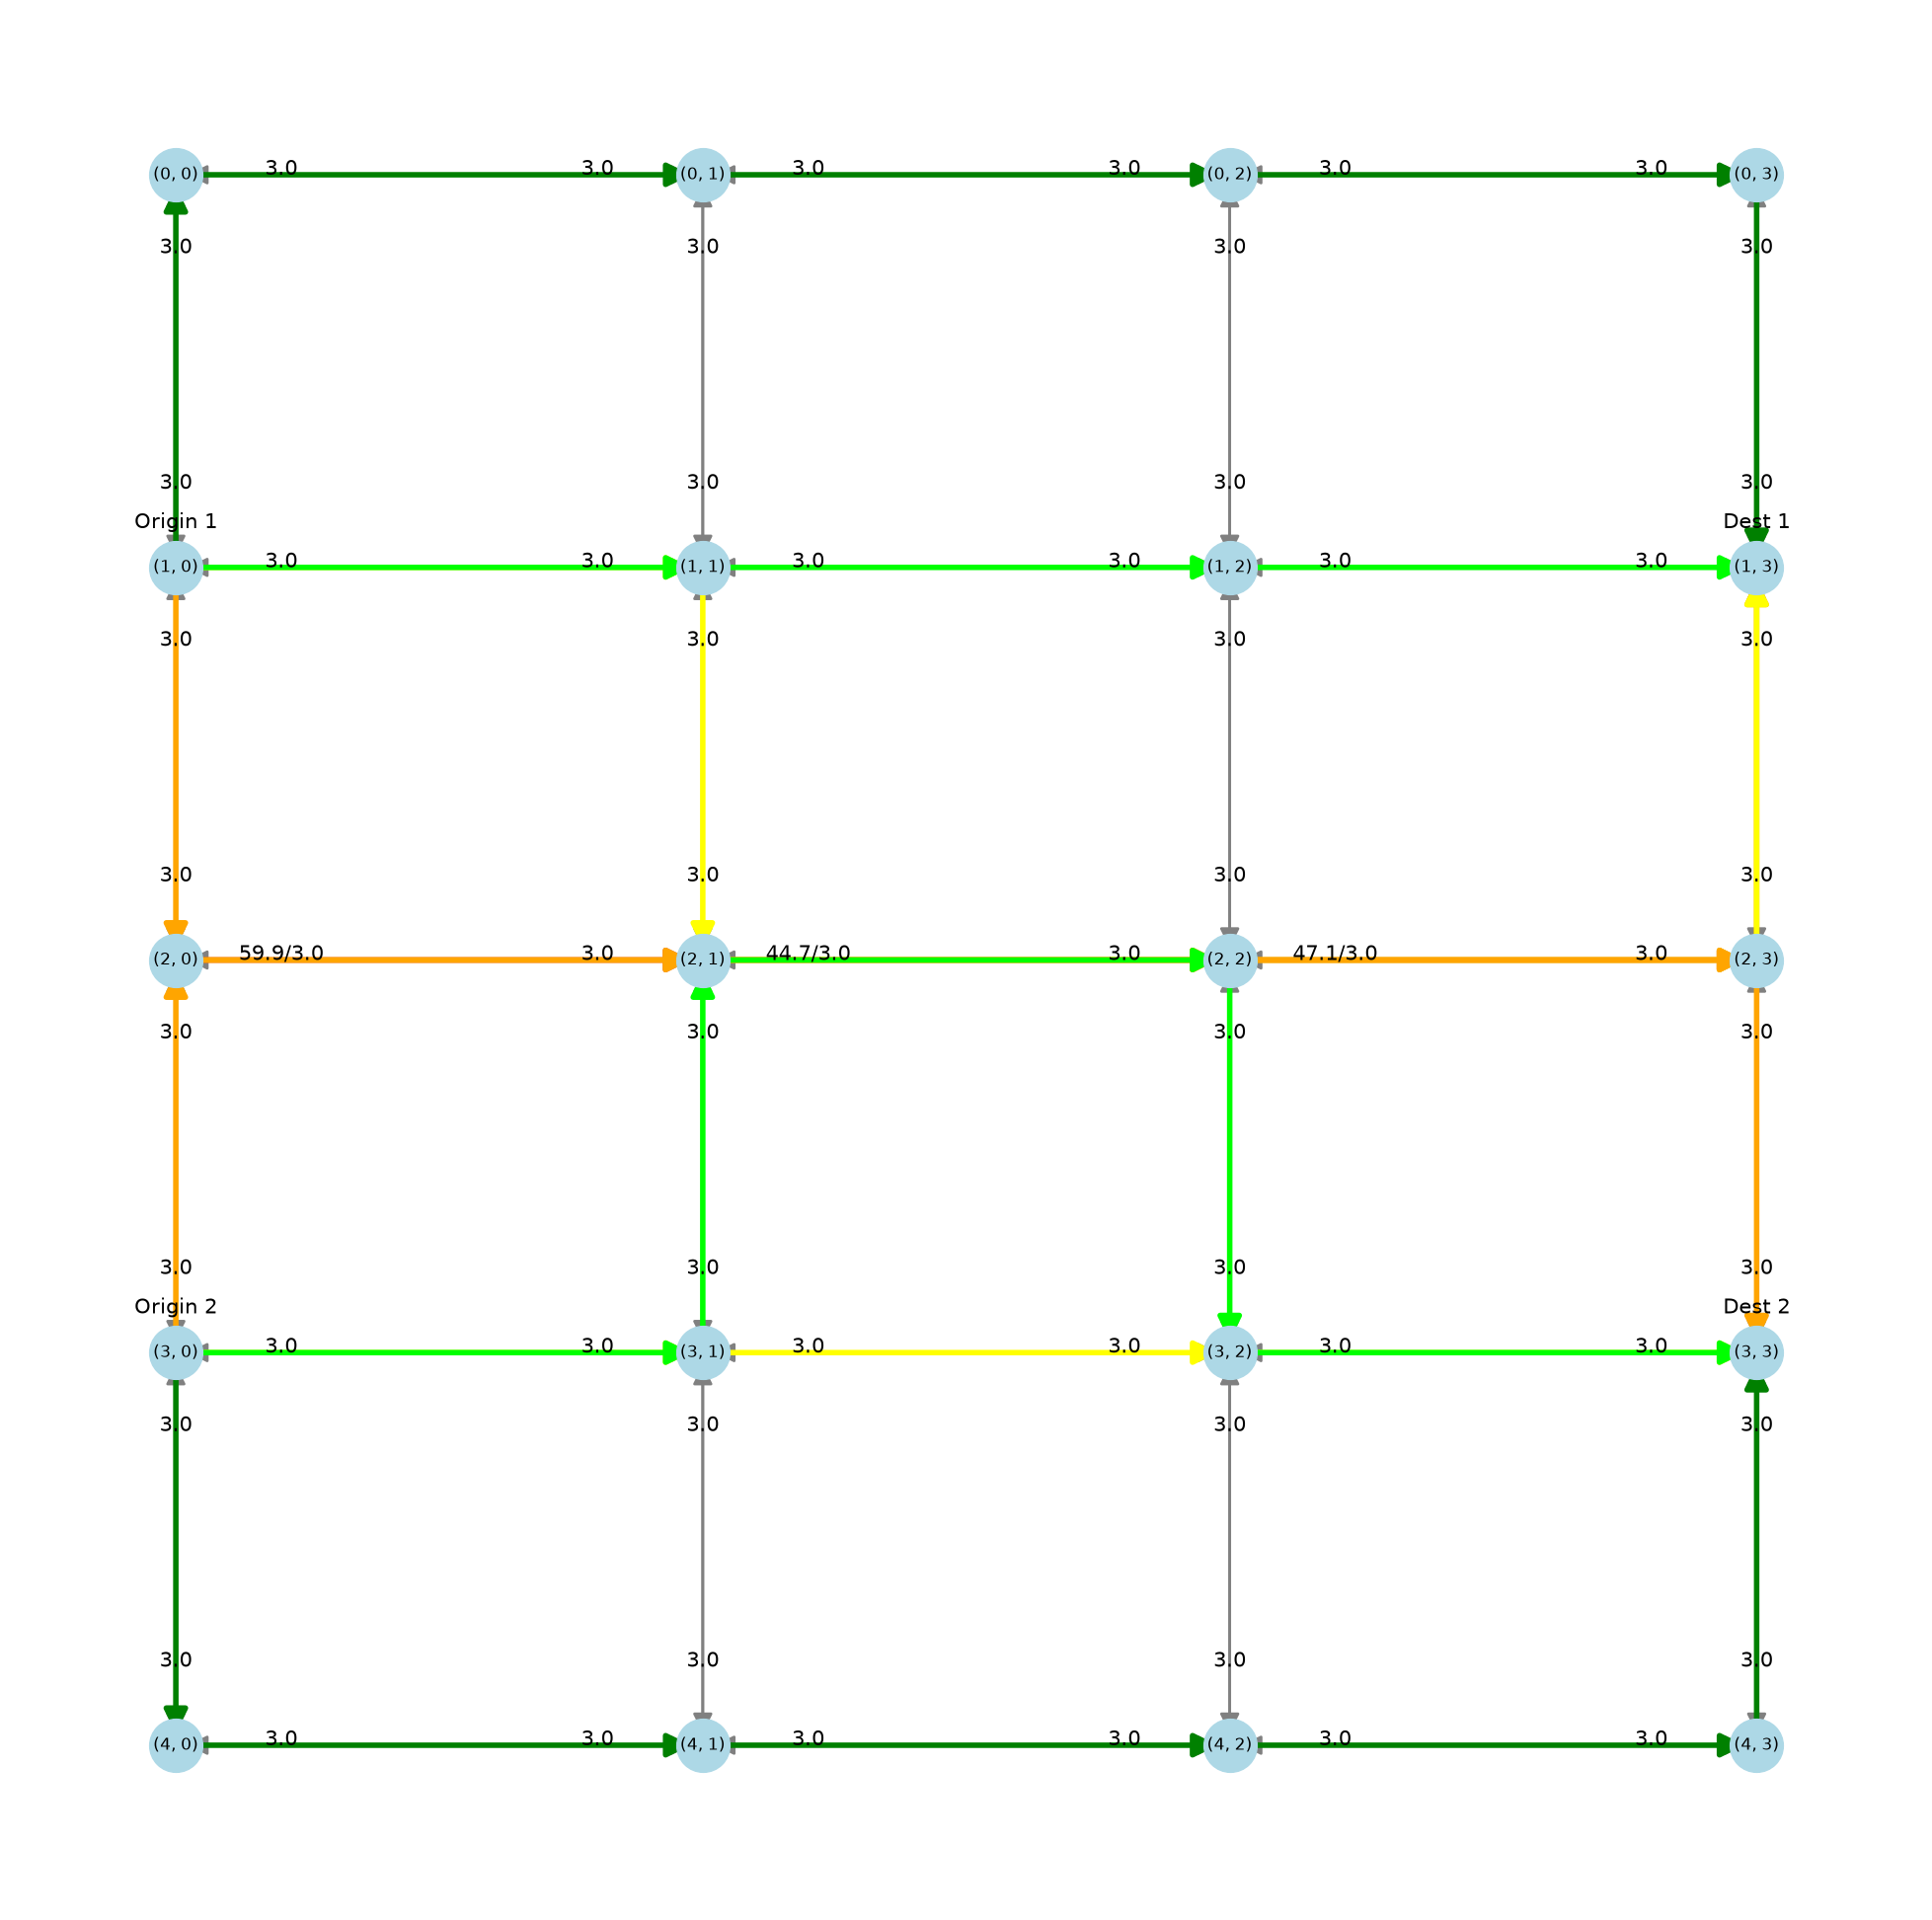

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = world.network.graph
pos = {(r, c): (c, -r) for (r, c) in G.nodes}

plt.figure(figsize=(25, 25))

# draw nodes & edges
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, G.edges(), edge_color="gray", arrows=True, width=2, arrowsize=30)

# draw arteries
nx.draw_networkx_edges(G, pos, edgelist=instance.arteries, edge_color="crimson", arrows=True, width=4, arrowsize=35)

# label origins & destinations
for i, (origin, dest) in enumerate(instance.demands, 1):
    (x0, y0), (x1, y1) = pos[origin], pos[dest]
    plt.text(x0, y0 + .1, f"Origin {i}", fontsize=15, ha="center")
    plt.text(x1, y1 + .1, f"Dest {i}", fontsize=15, ha="center")

# label origins & destinations
for arc in G.edges():
    (x0, y0), (x1, y1) = pos[arc[0]], pos[arc[1]]
    x, y = (x0 + x1) / 2, (y0 + y1) / 2
    x_offset = (x0 - x1) * .3
    y_offset = (y0 - y1) * .3
    c0, c1 = capacities["nominal"][arc], capacities["accident"][arc]
    capacity = f"{c0:.1f}" if c0 == c1 else f"{c0:.1f}/{c1:.1f}"
    plt.text(x + x_offset, y + y_offset, capacity, fontsize=15, ha="center")

# draw chosen k-shortest paths
colors = ["orange", "yellow", "lime", "green", "teal", "blue", "navy", "purple", "magenta"]
for od, paths in paths_per_od.items():
    for i, path in enumerate(paths):
        nx.draw_networkx_edges(G, pos, edgelist=path, edge_color=colors[i], arrows=True, width=4, arrowsize=35)

plt.axis(False)
plt.show()
